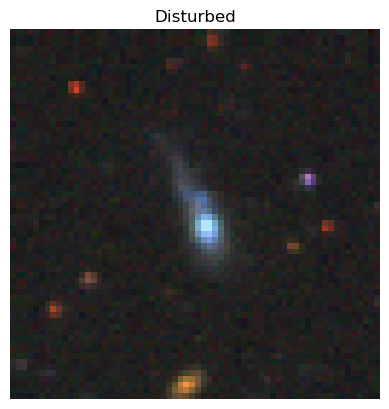

In [359]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

# Class names
CLASS_NAMES = [
    'Disturbed', 'Merging', 'Round Smooth', 'In-between Smooth',
    'Cigar Smooth', 'Barred Spiral', 'Unbarred Tight Spiral',
    'Unbarred Loose Spiral', 'Edge-on no Bulge', 'Edge-on with Bulge'
]

# Load dataset
with h5py.File('Galaxy10_DECals_64x64.h5', 'r') as F:
    images = np.array(F['images'])   # shape: (17736, 64, 64, 3)
    labels = np.array(F['ans'])      # integer labels 0-9

# Display galaxy 27
plt.imshow(images[27] / 255.0)
plt.title(CLASS_NAMES[labels[27]])
plt.axis('off')
plt.show()

## Task 1

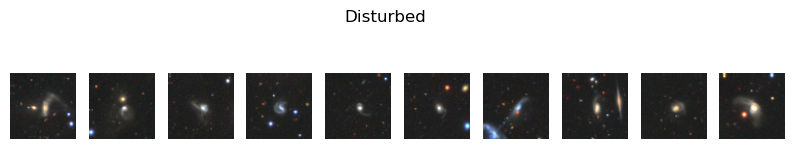

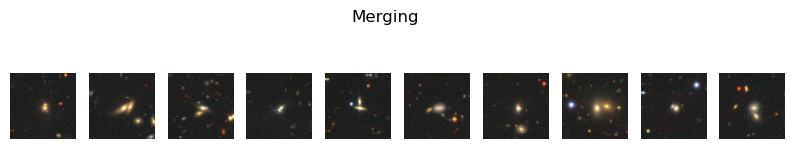

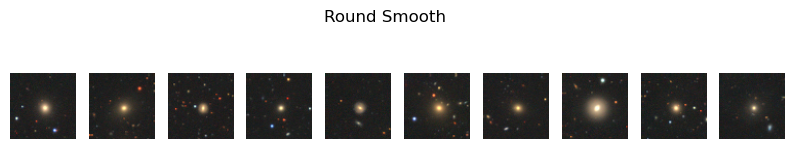

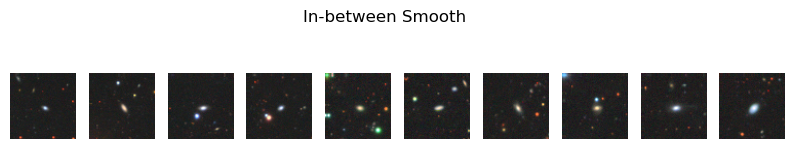

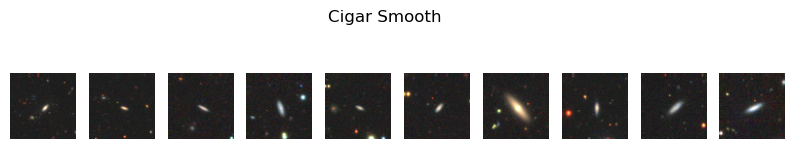

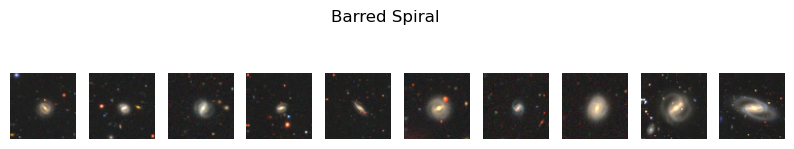

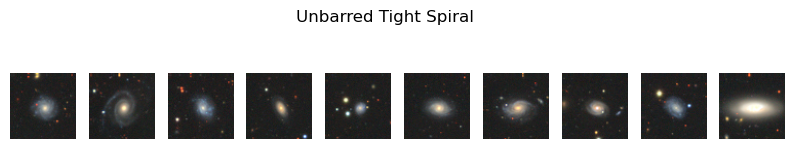

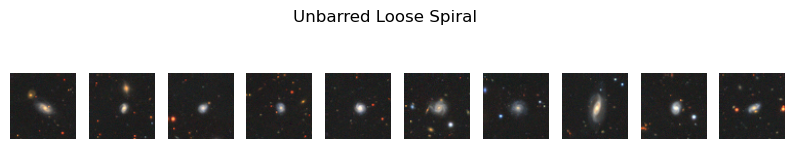

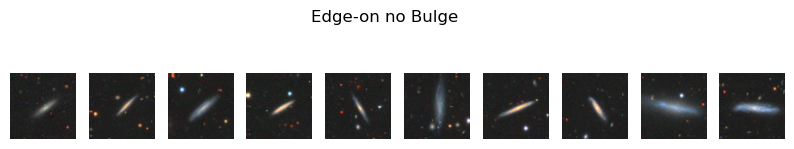

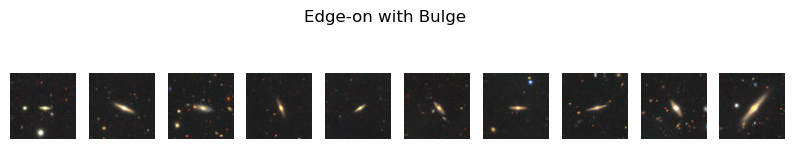

In [360]:
for i in range(10):
    idx = np.where(labels == i)[0]
    plt.figure(figsize=(10, 2))
    for j in range(10):
        plt.subplot(1, 10, j+1)
        plt.imshow(images[idx[j]] / 255.0)
        plt.axis('off')
    plt.suptitle(CLASS_NAMES[i])
    plt.show()

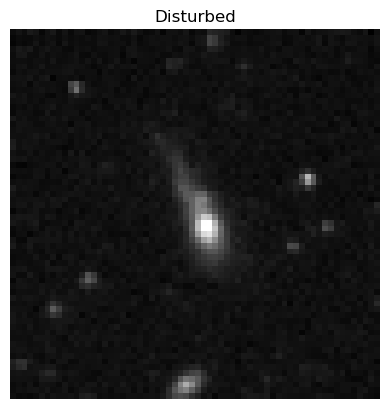

In [361]:
gray_images = np.mean(images, axis=-1)  # shape: (17736, 64, 64)
plt.imshow(gray_images[27], cmap='gray')
plt.title(CLASS_NAMES[labels[27]])
plt.axis('off')
plt.show()

In [362]:
shape = gray_images.shape
print(f"Shape of grayscale images: {shape}")

Shape of grayscale images: (17736, 64, 64)


## Task 2

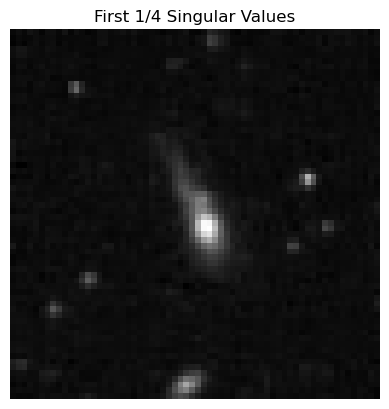

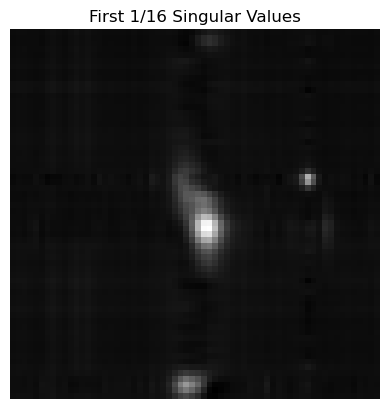

In [363]:
img = gray_images[27]  # shape (64, 64)
U, S, Vt = np.linalg.svd(img, full_matrices=False)

k = len(S) // 4
img_1_4 = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
plt.imshow(img_1_4, cmap="gray")
plt.title("First 1/4 Singular Values")  
plt.axis('off')
plt.show()
k = len(S) // 16
img_1_16 = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
plt.imshow(img_1_16, cmap="gray")
plt.title("First 1/16 Singular Values")
plt.axis('off')
plt.show()


## Task 3

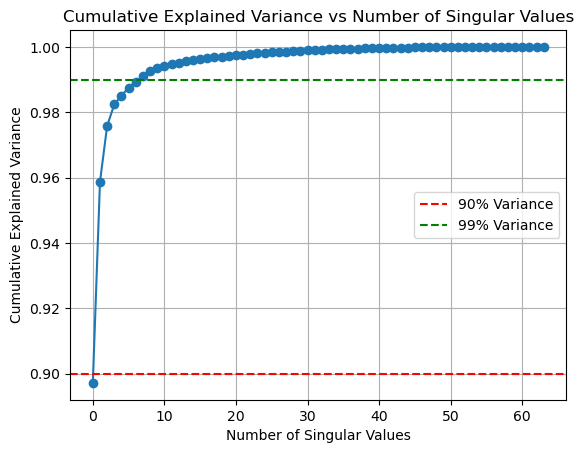

Number of singular values needed to explain 99% variance: 8
Number of singular values needed to explain 90% variance: 2


In [364]:
explained_variance = S**2
fractional_variance = explained_variance / np.sum(explained_variance)
cumulative_variance = np.cumsum(fractional_variance)
plt.plot(cumulative_variance, marker='o')   
plt.axhline(0.9, color='r', linestyle='--', label='90% Variance')
plt.axhline(0.99, color='g', linestyle='--', label='99% Variance')
plt.xlabel('Number of Singular Values')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs Number of Singular Values')
plt.legend()
plt.grid()
plt.show()
k_99 = np.argmax(cumulative_variance >= 0.99) + 1 
print(f"Number of singular values needed to explain 99% variance: {k_99}")
k_90 = np.argmax(cumulative_variance >= 0.90) + 1 
print(f"Number of singular values needed to explain 90% variance: {k_90}")

In [365]:
w_1 = 2.858
median = S[31]  # 32nd singular value (index 31)
print(f"32nd singular value: {median:.3f}")
index = 0
for sigma in S:
    index += 1
    if sigma > w_1 * median:
        print(f"{index}. Singular value {sigma:.3f} is larger than 2.858 * {median:.3f}")
    else:
        break   

32nd singular value: 23.668
1. Singular value 2239.678 is larger than 2.858 * 23.668
2. Singular value 586.648 is larger than 2.858 * 23.668
3. Singular value 309.465 is larger than 2.858 * 23.668
4. Singular value 191.425 is larger than 2.858 * 23.668
5. Singular value 123.098 is larger than 2.858 * 23.668
6. Singular value 115.918 is larger than 2.858 * 23.668
7. Singular value 103.269 is larger than 2.858 * 23.668
8. Singular value 96.053 is larger than 2.858 * 23.668
9. Singular value 89.299 is larger than 2.858 * 23.668
10. Singular value 71.305 is larger than 2.858 * 23.668


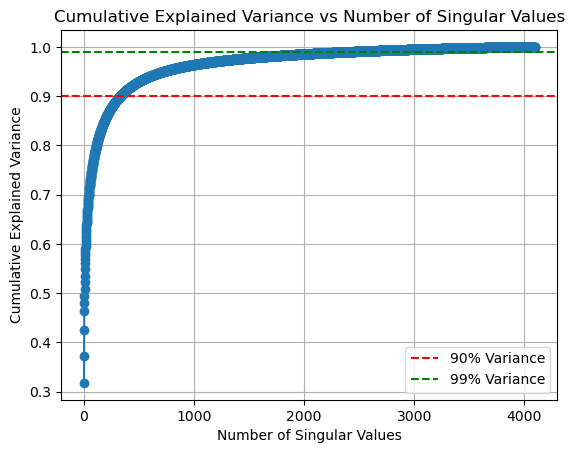

Number of singular values needed to explain 99% variance: 2387
Number of singular values needed to explain 90% variance: 329


In [366]:
flat_x = gray_images.reshape(gray_images.shape[0], -1)  # shape: (17736, 4096)
xmean = flat_x.mean(axis=0)
xcentered = flat_x - xmean
U, S, Vt = np.linalg.svd(xcentered, full_matrices=False)
explained_variance = S**2
fractional_variance = explained_variance / np.sum(explained_variance)
cumulative_variance = np.cumsum(fractional_variance)
plt.plot(cumulative_variance, marker='o')   
plt.axhline(0.9, color='r', linestyle='--', label='90% Variance')
plt.axhline(0.99, color='g', linestyle='--', label='99% Variance')
plt.xlabel('Number of Singular Values')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs Number of Singular Values')
plt.legend()
plt.grid()
plt.show()
k_99 = np.argmax(cumulative_variance >= 0.99) + 1 
print(f"Number of singular values needed to explain 99% variance: {k_99}")
k_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Number of singular values needed to explain 90% variance: {k_90}")


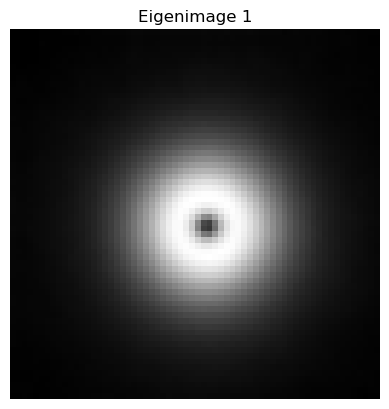

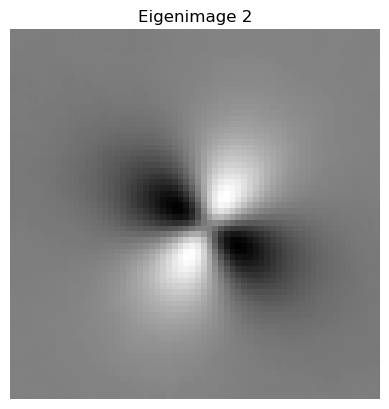

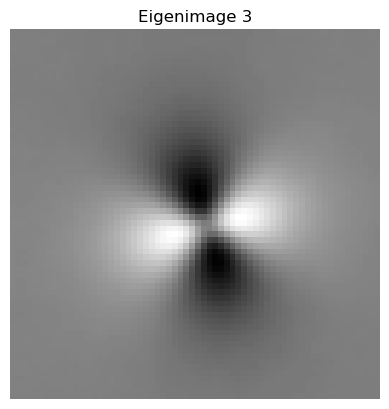

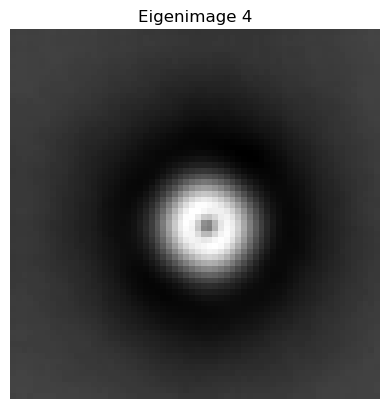

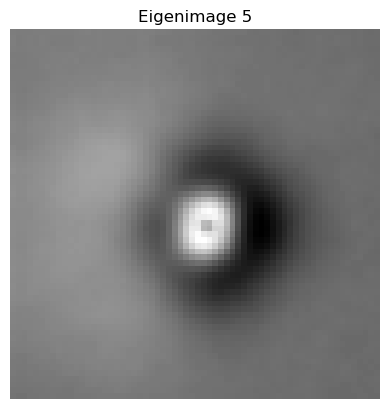

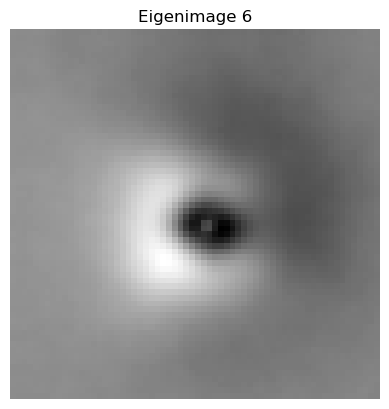

In [367]:
#eigenimages 
eigenimages = Vt[:6, :].reshape((6, 64, 64))
for i in range(6):
    plt.imshow(eigenimages[i], cmap='gray')
    plt.title(f"Eigenimage {i+1}")
    plt.axis('off')
    plt.show()

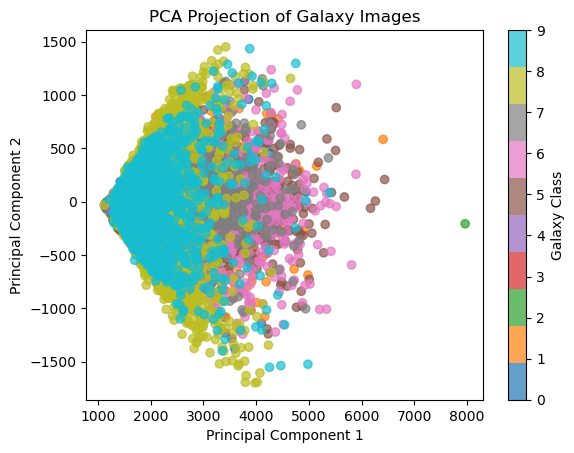

In [369]:
V2 = Vt[:2, :].T      
Z =  flat_x @ V2       
plt.scatter(Z[:, 0], Z[:, 1], c=labels, cmap='tab10', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Galaxy Images')
plt.colorbar(ticks=range(10), label='Galaxy Class')
plt.show()   

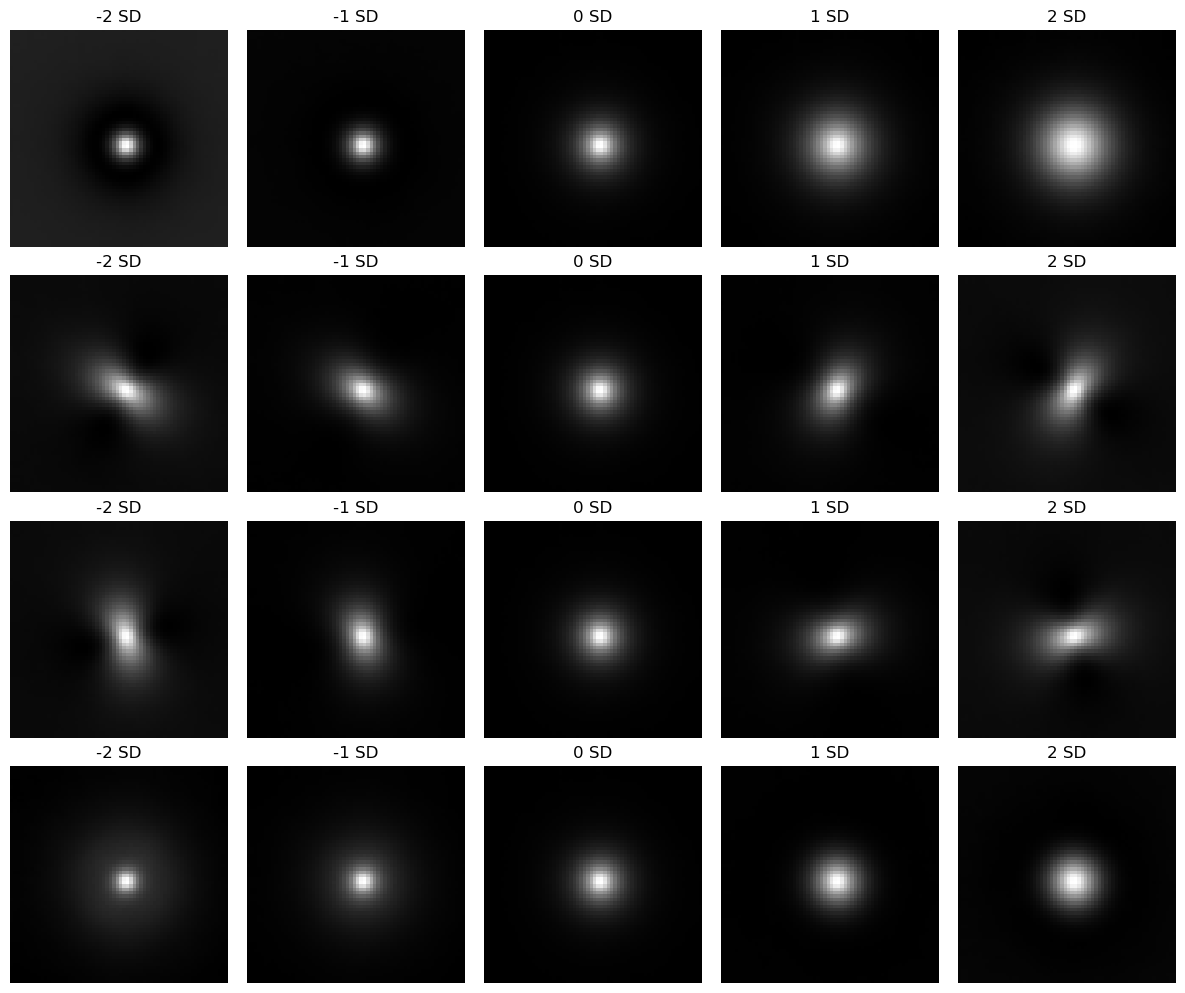

In [370]:
v4 = Vt[:4, :].T
Z4 = xcentered @ v4
sds = np.std(Z4, axis=0)

steps = [-2, -1, 0, 1, 2]

fig, axes = plt.subplots(4, 5, figsize=(12, 10))

for j in range(4):
    for i, a in enumerate(steps):
        z = np.zeros(4)
        z[j] = a * sds[j]

        xhat = xmean + v4 @ z
        img = xhat.reshape(64, 64)

        axes[j, i].imshow(img, cmap='gray')
        axes[j, i].axis('off')
        axes[j, i].set_title(f'{a} SD')

for j in range(4):
    axes[j, 0].set_ylabel(f'PC{j+1}', rotation=90, size=12)

plt.tight_layout()
plt.show()


## Task 4

In [13]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# reproducibility
torch.manual_seed(0)
np.random.seed(0)

# use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', device)

Using device: mps


In [14]:
print('Loaded:', gray_images.shape, '  dtype:', gray_images.dtype)
normalized_images = gray_images / 255.0
print('Pixel range: [{:.3f}, {:.3f}]'.format(normalized_images.min(), normalized_images.max()))

Loaded: (17736, 64, 64)   dtype: float64
Pixel range: [0.029, 1.000]


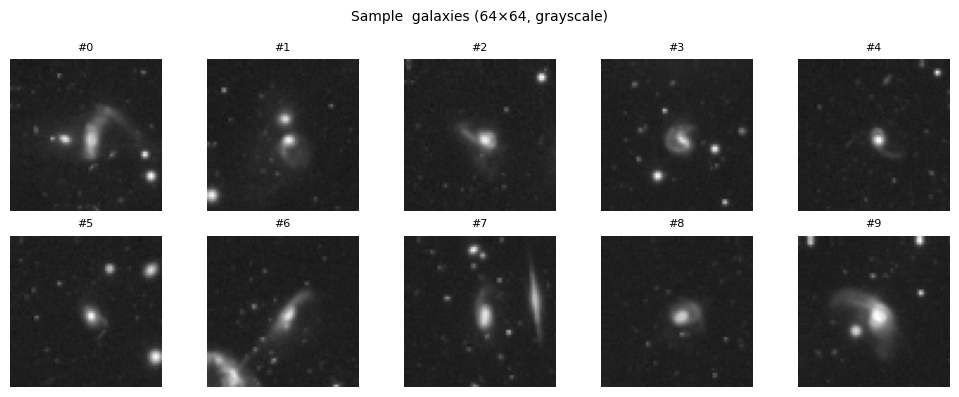

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(normalized_images[i], cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
    ax.set_title(f'#{i}', fontsize=8)
plt.suptitle('Sample  galaxies (64×64, grayscale)', fontsize=10)
plt.tight_layout()
plt.show()

In [16]:
N_TRAIN    = 14000
BATCH_SIZE = 32

# add channel dim: (N, 1, 64, 64)
x_train = torch.tensor(normalized_images[:N_TRAIN,  None, :, :], dtype=torch.float32)
x_val   = torch.tensor(normalized_images[N_TRAIN:,  None, :, :], dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(x_train, x_train),   # input == target (autoencoder)
    batch_size=BATCH_SIZE, shuffle=True
)

print(f'Training images:   {x_train.shape}')
print(f'Validation images: {x_val.shape}')

Training images:   torch.Size([14000, 1, 64, 64])
Validation images: torch.Size([3736, 1, 64, 64])


In [17]:
class ConvAutoencoder(nn.Module):
    """Convolutional autoencoder for square single-channel images."""

    def __init__(self, channels: int, size: int, latent_dim: int = 4):
        """
        Parameters
        ----------
        channels  : number of input channels (1 for grayscale)
        size      : spatial size of the input image (must be divisible by 8)
        latent_dim: dimension of the bottleneck (latent space)
        """
        super().__init__()
        assert size % 8 == 0, 'image size must be divisible by 8'
        self.latent_dim = latent_dim
        s = size // 8          # spatial size after 3 stride-2 convolutions
        self.s = s
        flat = 128 * s * s     # number of features before the bottleneck Dense

        # --- Encoder ---
        self.enc_conv = nn.Sequential(
            nn.Conv2d(channels, 32,  3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32,       64,  3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64,       128, 3, stride=2, padding=1), nn.ReLU(),
        )
        self.enc_fc = nn.Linear(flat, latent_dim)

        # --- Decoder ---
        self.dec_fc = nn.Linear(latent_dim, flat)
        self.dec_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 128, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(128,  64, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d( 64,  32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.Conv2d(32, channels, 3, stride=1, padding=1),
            nn.Sigmoid(),   # output in [0, 1] to match normalised pixel values
        )

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Map an image batch to latent vectors."""
        h = self.enc_conv(x)                      # (N, 128, s, s)
        h = h.view(h.size(0), -1)                 # (N, 128*s*s)  flatten
        return self.enc_fc(h)                      # (N, latent_dim)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """Map latent vectors back to images."""
        h = self.dec_fc(z)                         # (N, 128*s*s)
        h = h.view(h.size(0), 128, self.s, self.s) # (N, 128, s, s)  reshape
        return self.dec_conv(h)                    # (N, channels, H, W)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decode(self.encode(x))

In [18]:
LATENT_DIM = 4
SIZE       = 64
CHANNELS   = 1

model = ConvAutoencoder(channels=CHANNELS, size=SIZE, latent_dim=LATENT_DIM).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')
print(model)

Total trainable parameters: 406,533
ConvAutoencoder(
  (enc_conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (enc_fc): Linear(in_features=8192, out_features=4, bias=True)
  (dec_fc): Linear(in_features=4, out_features=8192, bias=True)
  (dec_conv): Sequential(
    (0): ConvTranspose2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): Sigmoid()
  )
)


In [19]:
EPOCHS = 50

optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

x_val_dev = x_val.to(device)

train_losses = []
val_losses   = []

for epoch in range(1, EPOCHS + 1):
    # --- training ---
    model.train()
    epoch_loss = 0.0
    for x_batch, _ in train_loader:
        x_batch = x_batch.to(device)

    


        optimizer.zero_grad()
        loss = loss_fn(model(x_batch), x_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x_batch.size(0)

    epoch_loss /= N_TRAIN
    train_losses.append(epoch_loss)

    # --- validation ---
    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(x_val_dev), x_val_dev).item()
    val_losses.append(val_loss)

    if epoch % 5 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS}  train loss: {epoch_loss:.5f}  val loss: {val_loss:.5f}')

print('Training complete.') 

Epoch   5/50  train loss: 0.00272  val loss: 0.00335
Epoch  10/50  train loss: 0.00257  val loss: 0.00328
Epoch  15/50  train loss: 0.00251  val loss: 0.00328
Epoch  20/50  train loss: 0.00245  val loss: 0.00322
Epoch  25/50  train loss: 0.00239  val loss: 0.00303
Epoch  30/50  train loss: 0.00235  val loss: 0.00320
Epoch  35/50  train loss: 0.00233  val loss: 0.00326
Epoch  40/50  train loss: 0.00230  val loss: 0.00333
Epoch  45/50  train loss: 0.00228  val loss: 0.00338
Epoch  50/50  train loss: 0.00226  val loss: 0.00336
Training complete.


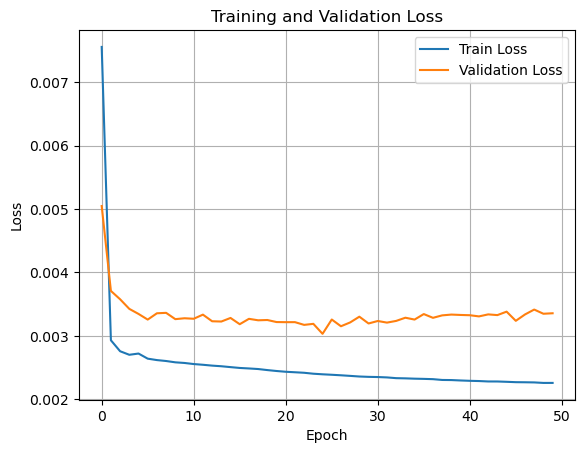

In [371]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')   
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid()
plt.show()

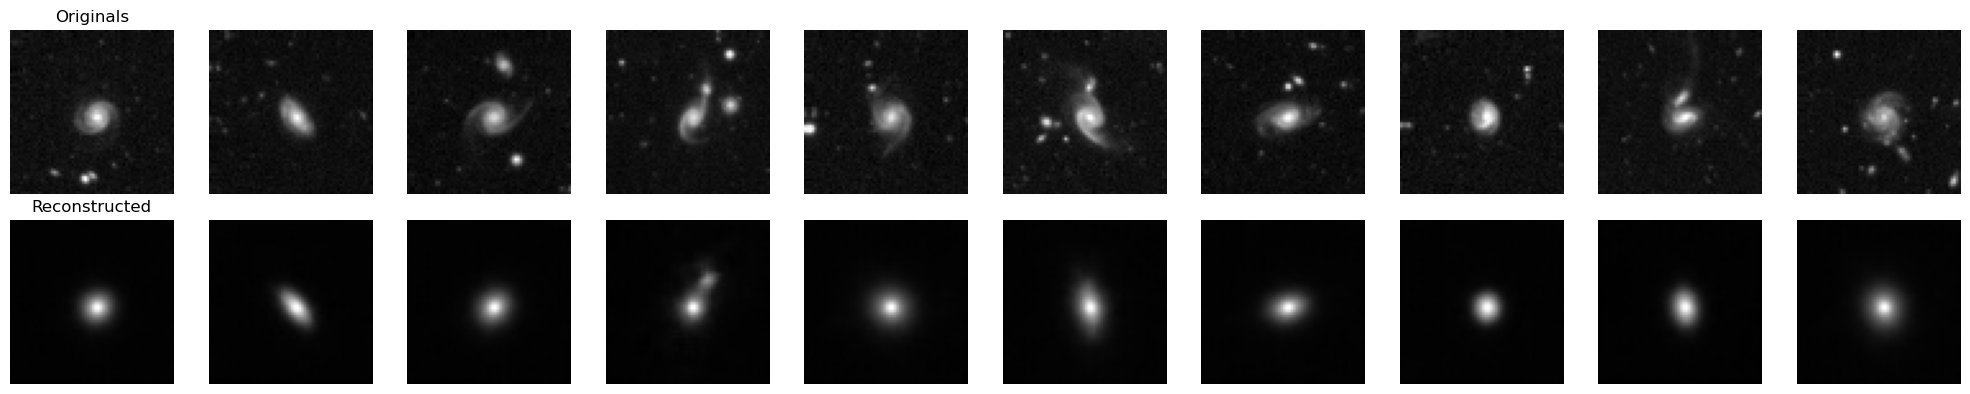

In [372]:
model.eval()
with torch.no_grad():
    # Pass the validation batch through the model
    reconstructed = model(x_val_dev)

original_np = x_val_dev.cpu().numpy()
recon_np = reconstructed.cpu().numpy()

# Create one large figure
plt.figure(figsize=(20, 4))

for j in range(10):
    # --- Top Row: Original Images ---
    plt.subplot(2, 10, j + 1)
    plt.imshow(original_np[j].reshape(64, 64), cmap='gray')
    if j == 0: 
        plt.title("Originals") # Only put title on the first one to save space
    plt.axis('off')

    # --- Bottom Row: Reconstructed Images ---
    # j + 11 shifts the plot to the second row (indices 11 through 20)
    plt.subplot(2, 10, j + 11) 
    plt.imshow(recon_np[j].reshape(64, 64), cmap='gray')
    if j == 0:
        plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [373]:
ANN_mse = loss_fn(reconstructed, x_val_dev).item()
print(f'Mean Squared Error on validation set: {ANN_mse:.5f}') 

Mean Squared Error on validation set: 0.00336


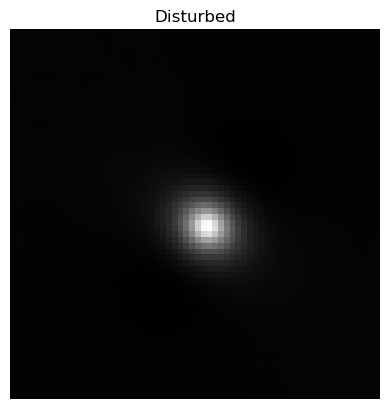

MSE: 187.47792488995026


In [374]:

X4 = U[:, :4] @ np.diag(S[:4]) @ Vt[:4, :]
reconstructed2 = X4 + xmean
reconstructed_images = reconstructed2.reshape(gray_images.shape)

plt.imshow(reconstructed_images[2], cmap='gray')
plt.title(CLASS_NAMES[labels[2]])
plt.axis('off')
plt.show()
mse = np.mean((flat_x - reconstructed2) ** 2)
print("MSE:", mse)

## Task 5

In [375]:
x_all_dev = x_all.to(device)
model.eval()
with torch.no_grad():
    z_val = model.encode(x_all_dev).cpu().numpy()

print('Latent vectors shape:', z_val.shape)
print('\nPer-dimension statistics:')
print(f'  {"dim":>3}  {"mean":>8}  {"std":>8}  {"min":>8}  {"max":>8}')
for i in range(LATENT_DIM):
    print(f'  {i:>3}  {z_val[:,i].mean():>8.3f}  {z_val[:,i].std():>8.3f}'
          f'  {z_val[:,i].min():>8.3f}  {z_val[:,i].max():>8.3f}')

Latent vectors shape: (17736, 4)

Per-dimension statistics:
  dim      mean       std       min       max
    0     0.439     0.614    -7.766     6.314
    1     0.047     0.756    -5.231    13.335
    2    -0.906     0.574    -4.626     6.716
    3     0.132     0.667   -10.479     4.473


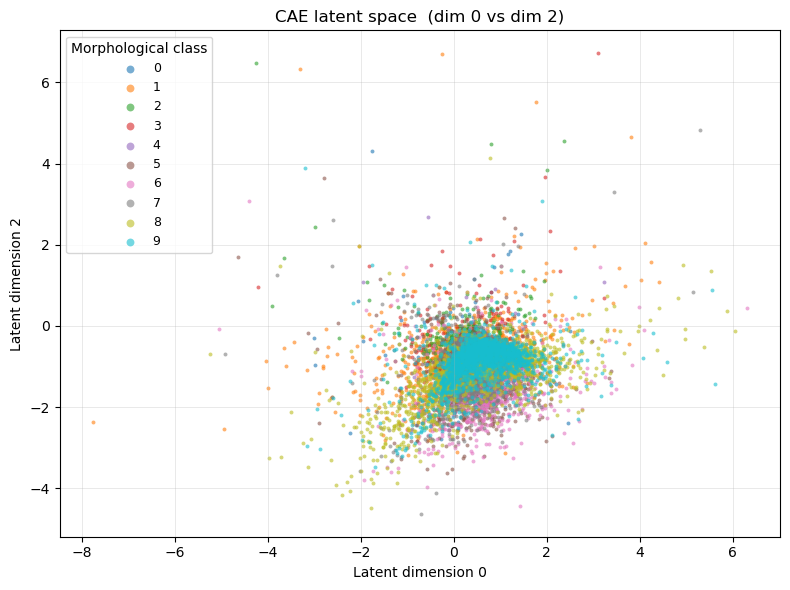

In [376]:
DIM_X, DIM_Y = 0, 2

class_names = np.unique(labels)
palette = plt.cm.tab10(np.linspace(0, 0.9, len(class_names)))

fig, ax = plt.subplots(figsize=(8, 6))

for cls, color in zip(class_names, palette):
    mask = labels == cls
    
    ax.scatter(
        z_val[mask, DIM_X],
        z_val[mask, DIM_Y],
        s=8,
        alpha=0.6,
        color=color,
        label=str(cls),
        linewidths=0,
    )

ax.set_xlabel(f'Latent dimension {DIM_X}')
ax.set_ylabel(f'Latent dimension {DIM_Y}')
ax.set_title(f'CAE latent space  (dim {DIM_X} vs dim {DIM_Y})')
ax.legend(title='Morphological class', markerscale=2, fontsize=9)
ax.grid(True, linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig('latent_space_scatter.png', dpi=150)
plt.show()

In [377]:
def latent_vector(n):
    std = z_val.std(axis=0)   

    vectors = np.zeros((5,4))
    for v in [-2, -1, 0, 1, 2]:
        vectors[v+2,n] = v * std[n]
    return vectors

In [378]:
z_d1 = torch.tensor(latent_vector(0), dtype = torch.float32)
z_d2 = torch.tensor(latent_vector(1), dtype = torch.float32)
z_d3 = torch.tensor(latent_vector(2), dtype = torch.float32)
z_d4 = torch.tensor(latent_vector(3), dtype = torch.float32)


model.eval()
with torch.no_grad():
    decoded1 = model.decode(z_d1.to(device)).cpu().numpy()
    decoded2 = model.decode(z_d2.to(device)).cpu().numpy()
    decoded3 = model.decode(z_d3.to(device)).cpu().numpy()
    decoded4 = model.decode(z_d4.to(device)).cpu().numpy()

decoded_all = [decoded1, decoded2, decoded3, decoded4]

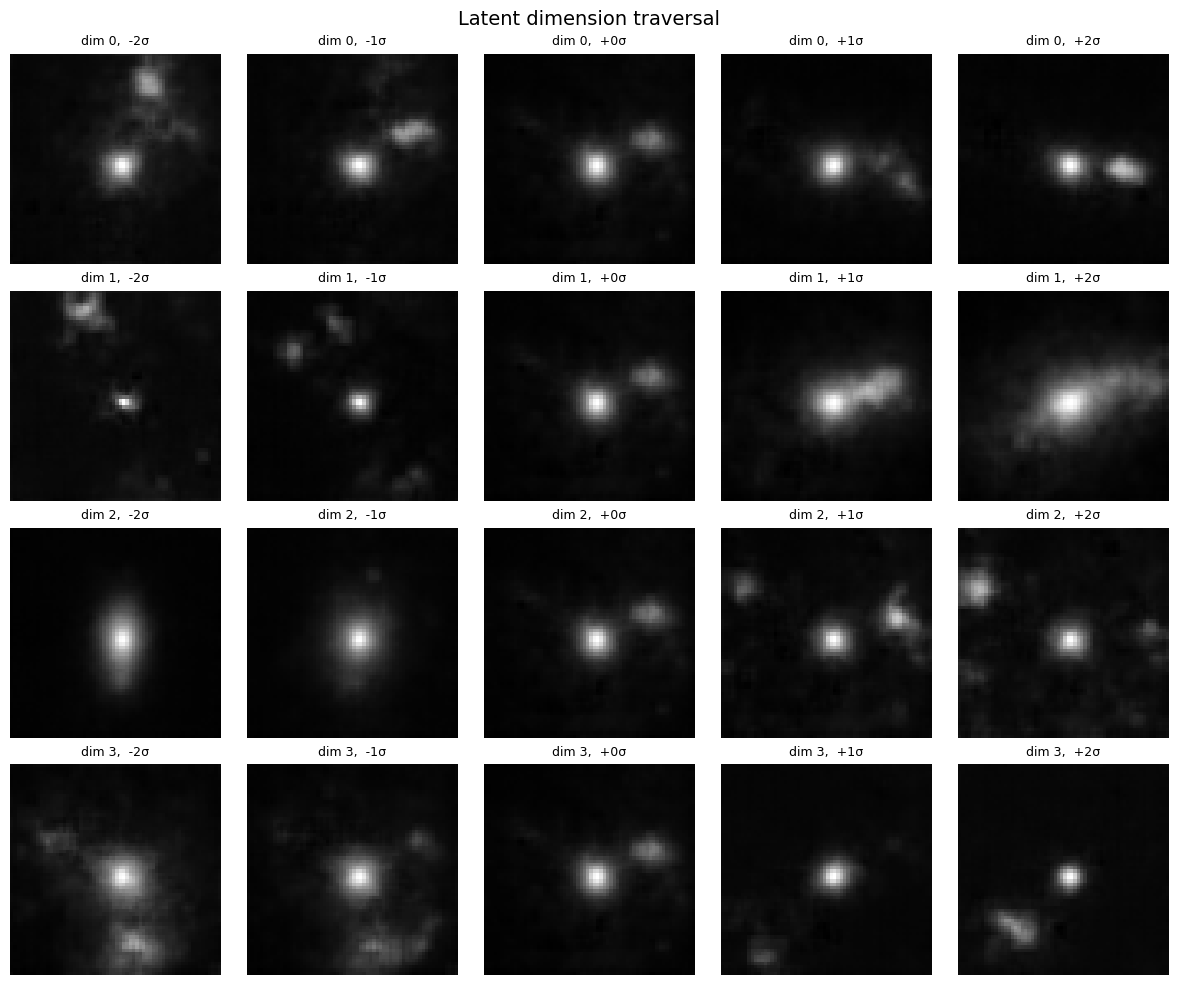

In [379]:
fig, axes = plt.subplots(4, 5, figsize=(12, 10))

values = [-2, -1, 0, 1, 2]

for dim, decoded in enumerate(decoded_all):
    for i, val in enumerate(values):
        ax = axes[dim, i]
        ax.imshow(decoded[i].reshape(64, 64), cmap='gray')
        ax.axis('off')
        
        ax.set_title(f'dim {dim},  {val:+d}σ', fontsize=9)  # jedes Bild einzeln beschriftet

plt.suptitle('Latent dimension traversal', fontsize=14)
plt.tight_layout()
plt.savefig('task5_3')
plt.show()

## Task 6

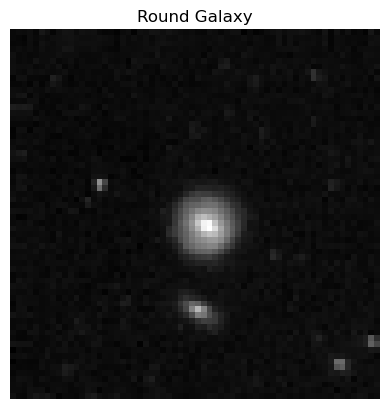

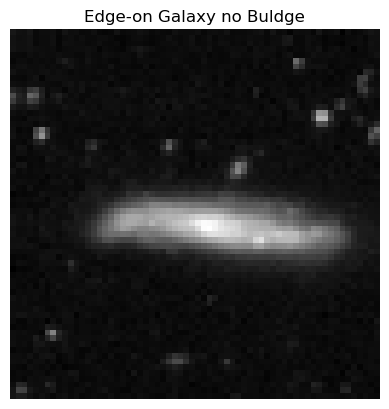

In [380]:
round_gal = normalized_images[np.where(labels == 2)][4]
edge_gal = normalized_images[np.where(labels == 8)][9]

plt.imshow(round_gal.reshape(64,64), cmap = 'gray')
plt.title("Round Galaxy")
plt.axis("off")
plt.show()

plt.imshow(edge_gal.reshape(64, 64), cmap = 'gray')
plt.title("Edge-on Galaxy no Buldge")
plt.axis("off")
plt.show()

In [381]:
round_gal_tens = torch.tensor(round_gal, dtype = torch.float32).unsqueeze(0).unsqueeze(0)
edge_gal_tens = torch.tensor(edge_gal, dtype = torch.float32).unsqueeze(0).unsqueeze(0)

model.eval()
with torch.no_grad():
    z_round = model.encode(round_gal_tens.to(device)).cpu().numpy()
    z_edge = model.encode(edge_gal_tens.to(device)).cpu().numpy()

print("latent vector of round galaxy: ", z_round)
print("latent vector of edge on galaxy: ", z_edge)

latent vector of round galaxy:  [[ 0.35118204 -0.39215356 -0.48785636  0.34799498]]
latent vector of edge on galaxy:  [[ 2.459743    0.5761841  -0.46715078  0.25193715]]


In [382]:
#interpolating svd:
Vt_90 = Vt[:329] 

mean_image = normalized_images.mean(axis=0).flatten()

round_flat = round_gal.flatten() - mean_image
edge_flat  = edge_gal.flatten()  - mean_image

score_round = Vt_90 @ round_flat
score_edge  = Vt_90 @ edge_flat

alphas_svd = [0, 0.25, 0.5, 0.75, 1]
svd_recons = []
for a in alphas_svd:
    score_a = (1 - a) * score_edge + a * score_round   # interpolierter PC-Vektor
    recon = Vt_90.T @ score_a + mean_image              # zurück in Bildraum
    svd_recons.append(recon.reshape(64, 64))

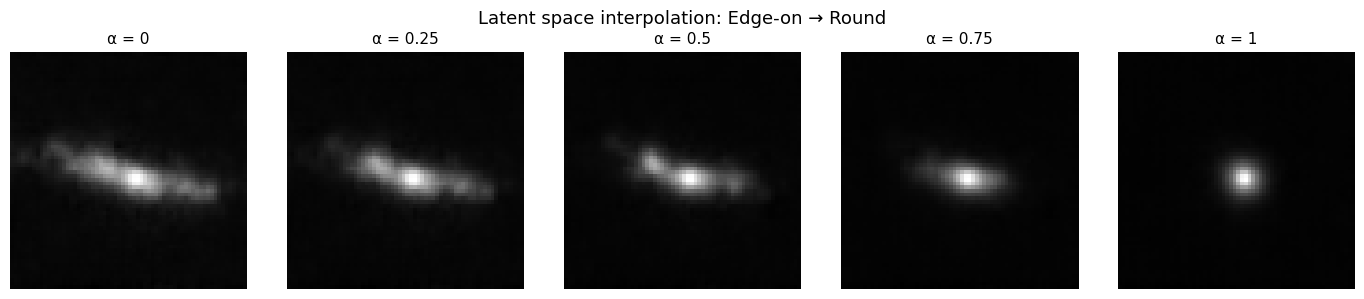

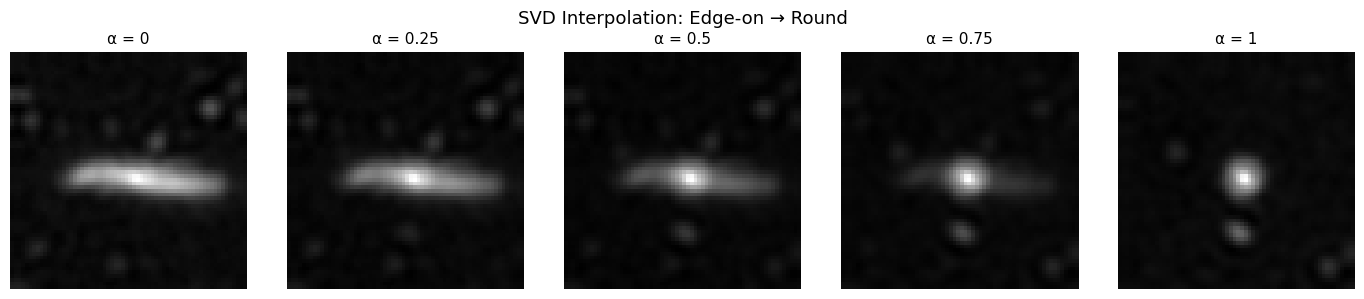

In [383]:
alphas = [0, 0.25, 0.5, 0.75, 1]

fig, axes = plt.subplots(1, len(alphas), figsize=(14, 3))

model.eval()
#plot cae:
for ax, a in zip(axes, alphas):
    z_a = (1 - a) * z_edge + a * z_round
    with torch.no_grad():
        decoded_a = model.decode(torch.tensor(z_a, dtype=torch.float32).to(device)).cpu().numpy()
    ax.imshow(decoded_a.reshape(64, 64), cmap='gray')
    ax.axis('off')
    ax.set_title(f'α = {a}', fontsize=11)

plt.suptitle('Latent space interpolation: Edge-on → Round', fontsize=13)
plt.tight_layout()
plt.savefig("task6a.png")
plt.show()

#plot svd:
fig, axes = plt.subplots(1, len(alphas), figsize=(14, 3))


for ax, n, a in zip(axes, range(len(alphas)), alphas):
    ax.imshow(svd_recons[n], cmap='gray')
    ax.axis('off')
    ax.set_title(f'α = {a}', fontsize=11)

plt.suptitle('SVD Interpolation: Edge-on → Round', fontsize=13)
plt.tight_layout()
plt.savefig("task6b.png")
plt.show()